# Generate trajectory by interpolation

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate
import plotly.graph_objects as go
import imageio
import base64
import io
from PIL import Image

from utils import MapIntergratedVisualizer, interpolate_closed_curve, smoothen_trajectory

In [13]:
# %pip install nbformat


In [14]:
import pandas as pd

pgm_file = "/home/praks/waypoints/race3.pgm"
origin = [-24.3, -9.81, 0]  # [origin_x, origin_y, rotation]
resolution = 0.05

# Load the file correctly
csv_path = 'second_attempt/centerline_for_race.csv'
full_raceline_df = pd.read_csv(csv_path, comment='#', delimiter=';', header=None)

# Set the correct columns
# full_raceline_df.columns = [
#     's_m', 'x_m', 'y_m', 'psi_rad', 'kappa_radpm', 'vx_mps', 'ax_mps2'
# ][:full_raceline_df.shape[1]]

full_raceline_df.columns = [
    'x','y','speed','lookahead'
][:full_raceline_df.shape[1]]

# Extract x, y, and yaw
x = full_raceline_df['x'].to_numpy()
y = full_raceline_df['y'].to_numpy()
# yaw = full_raceline_df['psi_rad'].to_numpy()

# Subsample every 500th point
# x = x[::100]
# y = y[::100]
# yaw = yaw[::500]

# Initialize the map visualizer
map_viz = MapIntergratedVisualizer(pgm_file, origin, resolution)
fig = map_viz.init_map()

# Plot points
fig = map_viz.add_scatter_points(fig, x=x, y=y)

# Plot yaw arrows
# fig = map_viz.add_yaw_arrows(fig, x=x, y=y, yaw=yaw)


fig.show()
# Show the figure
# fig.show(renderer="browser")

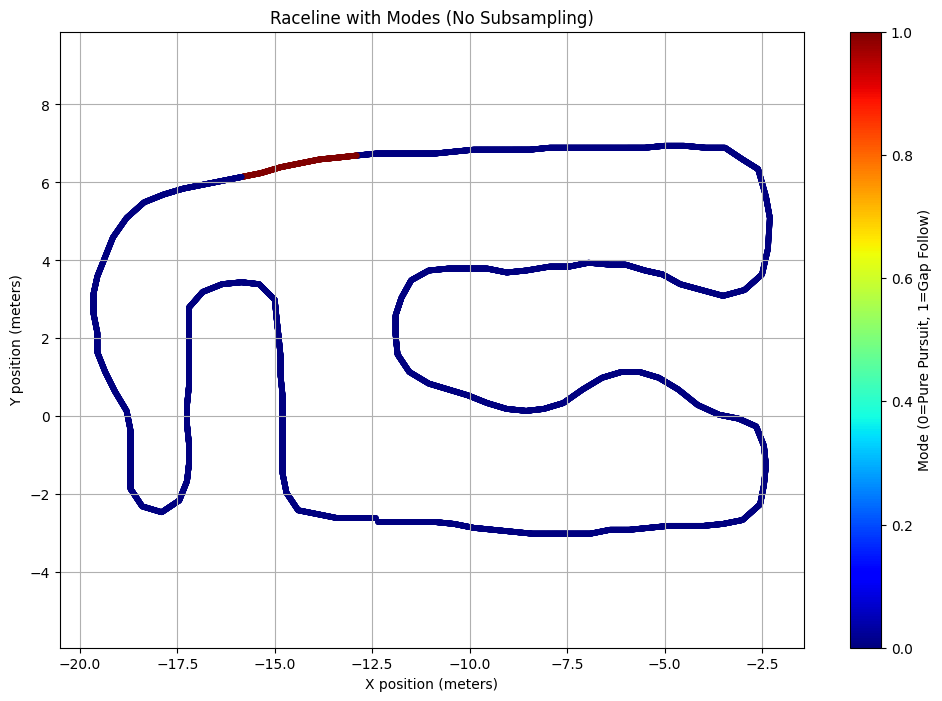

In [15]:

mode = np.zeros_like(full_raceline_df['x'], dtype=int) # default is pure pursuit 

# # 1 is for Gap follow
# # 0 is for pure pursuit 

# === Define helper function to set mode ===
def set_mode(mode_arr, start_idx, end_idx, mode_value):
    mode_arr[start_idx:end_idx] = mode_value

# === Apply custom mode zones ===
# 1 is for Gap Follow, 0 is for Pure Pursuit

# Set mode for the segment from 7249 to 9800
set_mode(mode, 7249, 9287, 1)

# Handle the wraparound between 13613 and 0, and 0 to 2185
# 1. First set the mode from 13613 to the end of the array (if needed)
set_mode(mode, 13613, len(x), 1)

# 2. Then set the mode from 0 to 2185
set_mode(mode, 0, 2185, 1)


masking = np.zeros_like(full_raceline_df['x'], dtype=int) # default is pure pursuit 
def set_mask(mask, start_idx, end_idx, mode_value):
        mask[start_idx:end_idx] = mode_value

# # 1 is form mask
# # 0 otherwise


# Set mode for the segment from 7249 to 9800
set_mask(masking, 9000, 9600, 1)


# === Plot the full data with mode coloring ===
plt.figure(figsize=(12, 8))
sc = plt.scatter(x, y, c=masking, cmap='jet', s=10)  # s=10 for point size
plt.colorbar(sc, label='Mode (0=Pure Pursuit, 1=Gap Follow)')
plt.title('Raceline with Modes (No Subsampling)')
plt.xlabel('X position (meters)')
plt.ylabel('Y position (meters)')
plt.axis('equal')
plt.grid(True)
plt.show()




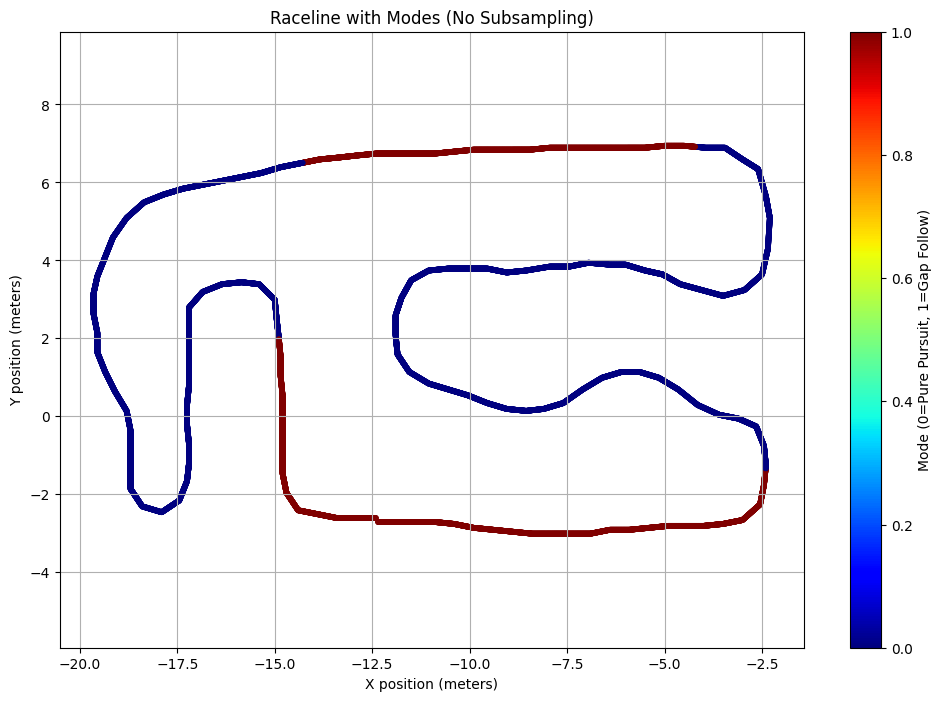

In [16]:
# === Plot the full data with mode coloring ===
plt.figure(figsize=(12, 8))
sc = plt.scatter(x, y, c=mode, cmap='jet', s=10)  # s=10 for point size
plt.colorbar(sc, label='Mode (0=Pure Pursuit, 1=Gap Follow)')
plt.title('Raceline with Modes (No Subsampling)')
plt.xlabel('X position (meters)')
plt.ylabel('Y position (meters)')
plt.axis('equal')
plt.grid(True)
plt.show()


Explicitly reducing speed 

With speed save

In [17]:
# === Add the mode column to the DataFrame ===
full_raceline_df['mode'] = mode
full_raceline_df['mask'] = masking


# === Save the updated DataFrame to a new CSV file ===
output_csv_path = 'second_attempt/centerline_with_mode.csv'
full_raceline_df.to_csv(output_csv_path, sep=';', index=False)
full_raceline_df.to_csv(output_csv_path, sep=';', index=False)


print(f"File saved successfully to {output_csv_path}")


File saved successfully to second_attempt/centerline_with_mode.csv
